In [126]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.io

from OMPython import ModelicaSystem

In [127]:
# Configure Matplotlib to use LaTeX
# plt.style.use('seaborn')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.minor.width'] = 1.5
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.size'] = 3

# Activate LaTeX style if supported
plt.rc('text', usetex = True )
plt.rc('font', family ='serif')

In [ ]:
pkg_dir_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum'
pkg_file_path = pkg_dir_path / 'package.mo'
model_file_path = pkg_dir_path / 'Demo_Driven.mo'
model = ModelicaSystem(str(pkg_file_path), 'ControlledPendulum.Demo_Driven')


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.



In [129]:
parameters = model.getParameters()
components = set()
for parameter in parameters.keys():
    components.add(parameter.split('.')[0])

comp_dict = {comp: {} for comp in components}
for parameter, value in parameters.items():
    comp, param = parameter.split('.')[0], parameter.split('.')[1]
    comp_dict[comp][param] = value

In [130]:
# Print all components and their parameters niceley
for comp, params in comp_dict.items():
    print(f"Component: {comp}")
    for param, value in params.items():
        print(f"  {param}: {value}")
    print()

Component: sensor_state
  delta: None
  levels: None
  nBits: 8.0
  q_max: None
  q_min: None

Component: sensor_ref
  delta: None
  levels: None
  nBits: 8.0
  q_max: None
  q_min: None

Component: pid
  D: None
  I: false
  Nd: 10.0
  P: 1.0
  Td: 0.2
  Ti: 0.1
  addErr: -1.0
  gainK: None
  k: 10.0
  lim: false
  sumPID: 1.0
  uMax: 1.0
  uMin: -1.0

Component: reference
  amplitude: 0.3490658503988659
  frequency: 0.25
  mean: 0.0

Component: drive
  L_M: 1.21e-4
  R_M: 0.151
  U_M: 16.0
  U_rated: 48.0
  eta_M: 0.85
  i_M: 60.0
  k_M: 0.03
  k_e: None
  k_n: None
  n_0: 12916.0

Component: pendulum
  L: 0.6055028481722639
  g: 9.81
  inertia: 18.90035177381065
  m: 41.70369562497543
  omega0: 0.0
  q0: 0.0



In [131]:
optimization_opts = model.getOptimizationOptions()
simulation_opts = model.getSimulationOptions()

# optimization_opts['startTime'] = 0.0
# optimization_opts['stopTime']  = 10.0
# optimization_opts['stepSize']  = 0.01
# optimization_opts['tolerance'] = 1e-6
# optimization_opts['numberOfIntervals'] = 1000

# simulation_opts['startTime'] = str(optimization_opts['startTime'])
# simulation_opts['stopTime']  = str(optimization_opts['stopTime'])
# simulation_opts['stepSize']  = str(optimization_opts['stepSize'])
# simulation_opts['tolerance'] = str(optimization_opts['tolerance'])

# model.setOptimizationOptions(optimization_opts)
# model.setSimulationOptions(simulation_opts)


In [132]:
simulation_options = [
    "startTime=0.0",
    "stopTime=10.0",        
    "stepSize=0.01",
    "tolerance=1e-6"
]

model.setSimulationOptions(simulation_options)
model.buildModel()
model.simulate()


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [133]:
solutions_dict = {}
solutions = model.getSolutions()
for sol in solutions:
    solutions_dict[sol] = model.getSolutions(sol)

res_file = Path.cwd() / 'results/reference.mat'
scipy.io.savemat(str(res_file), solutions_dict)

results = scipy.io.loadmat(str(res_file))
for sol in solutions:
    results[sol] = results[sol].flatten()

In [134]:
time = results['time']
q_ref = results['reference.q_ref']
q_state = results['pendulum.q']

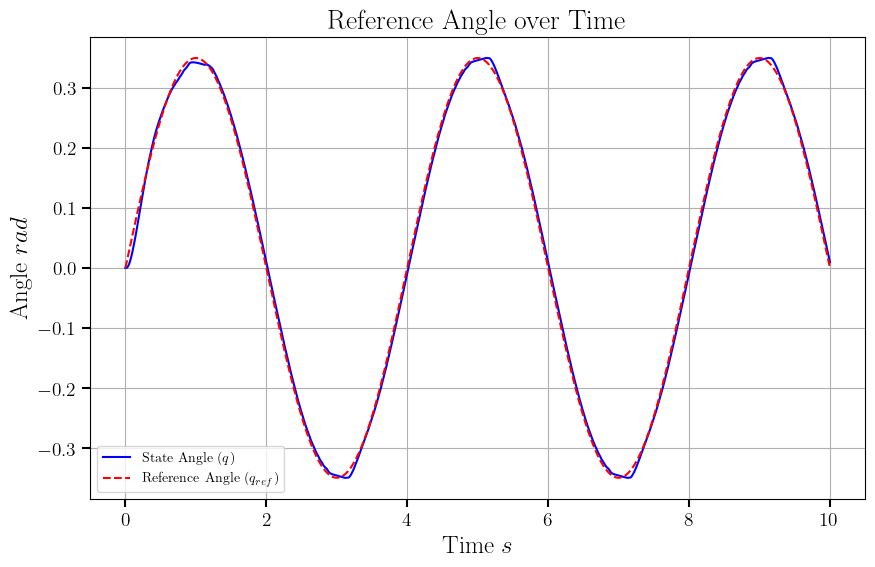

In [135]:
title_style = {'fontsize': 20, 'fontweight': 'bold'}
label_style = {'fontsize': 18}
legend_style = {}
    
plt.figure(figsize=(10, 6))
plt.plot(time, q_state, label='State Angle ($q$)', color='blue')
plt.plot(time, q_ref, label='Reference Angle ($q_{ref}$)', color='red', linestyle='--')
plt.title('Reference Angle over Time', **title_style)
plt.xlabel('Time $s$', **label_style)
plt.ylabel('Angle $rad$', **label_style)
plt.grid(True)
plt.legend(**legend_style)
plt.savefig('figures/reference_angle.svg', format='svg')
plt.show()
